In [2]:
# ── CÉLULA 0: setup e carregamento do trace da Fase 2 ───────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from scipy.stats import gaussian_kde

BASE = '/content/drive/MyDrive/Inferência Bayesiana Aplicada'

# Carregar dataset limpo
df = pd.read_parquet(f'{BASE}/data/clean/ab_test_clean.parquet')

# Dados agregados
n_ad,  conv_ad  = int((df.test_group=='ad').sum()),  int(df[df.test_group=='ad']['converted'].sum())
n_psa, conv_psa = int((df.test_group=='psa').sum()), int(df[df.test_group=='psa']['converted'].sum())

# Recriar o modelo e trace da Fase 2 (necessário para ROPE e BF)
with pm.Model() as modelo_ab:
    theta_ad  = pm.Beta('theta_ad',  alpha=2, beta=98)
    theta_psa = pm.Beta('theta_psa', alpha=2, beta=98)
    obs_ad    = pm.Binomial('obs_ad',  n=n_ad,  p=theta_ad,  observed=conv_ad)
    obs_psa   = pm.Binomial('obs_psa', n=n_psa, p=theta_psa, observed=conv_psa)
    delta     = pm.Deterministic('delta', theta_ad - theta_psa)
    lift      = pm.Deterministic('lift',  (theta_ad - theta_psa) / theta_psa)
    trace     = pm.sample(draws=2000, chains=4, target_accept=0.9,
                          return_inferencedata=True, progressbar=True)

samples_delta = trace.posterior['delta'].values.flatten()
hdi_delta     = az.hdi(trace, var_names=['delta'], hdi_prob=0.95)['delta'].values

print(f"✓ Dataset: {df.shape}")
print(f"✓ Trace: {len(samples_delta):,} amostras")
print(f"✓ HDI 95% delta: [{hdi_delta[0]:.6f}, {hdi_delta[1]:.6f}]")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Output()

✓ Dataset: (588101, 7)
✓ Trace: 8,000 amostras
✓ HDI 95% delta: [0.005978, 0.009500]


In [3]:
# ── CÉLULA 1: ROPE ───────────────────────────────────────────────────────────
rope_width = 0.001  # 0.1pp — limiar de relevância prática

rope_low  = -rope_width
rope_high = +rope_width

p_dentro_rope = ((samples_delta >= rope_low) & (samples_delta <= rope_high)).mean()
p_fora_rope   = 1 - p_dentro_rope

hdi_fora  = hdi_delta[0] > rope_high or hdi_delta[1] < rope_low
hdi_dent  = hdi_delta[0] >= rope_low  and hdi_delta[1] <= rope_high

if hdi_fora:
    decisao = '✓ IMPLANTAR — HDI completamente fora do ROPE'
elif hdi_dent:
    decisao = '✗ NÃO IMPLANTAR — HDI completamente dentro do ROPE'
else:
    decisao = '⚠ INCONCLUSIVO — HDI sobrepõe parcialmente o ROPE'

print('ANÁLISE ROPE')
print('─'*48)
print(f'  ROPE             : [{rope_low:.4f}, {rope_high:.4f}]')
print(f'  HDI 95% delta    : [{hdi_delta[0]:.6f}, {hdi_delta[1]:.6f}]')
print(f'  P(dentro ROPE)   : {p_dentro_rope:.6%}')
print(f'  P(fora ROPE)     : {p_fora_rope:.6%}')
print(f'  Decisão          : {decisao}')

ANÁLISE ROPE
────────────────────────────────────────────────
  ROPE             : [-0.0010, 0.0010]
  HDI 95% delta    : [0.005978, 0.009500]
  P(dentro ROPE)   : 0.000000%
  P(fora ROPE)     : 100.000000%
  Decisão          : ✓ IMPLANTAR — HDI completamente fora do ROPE


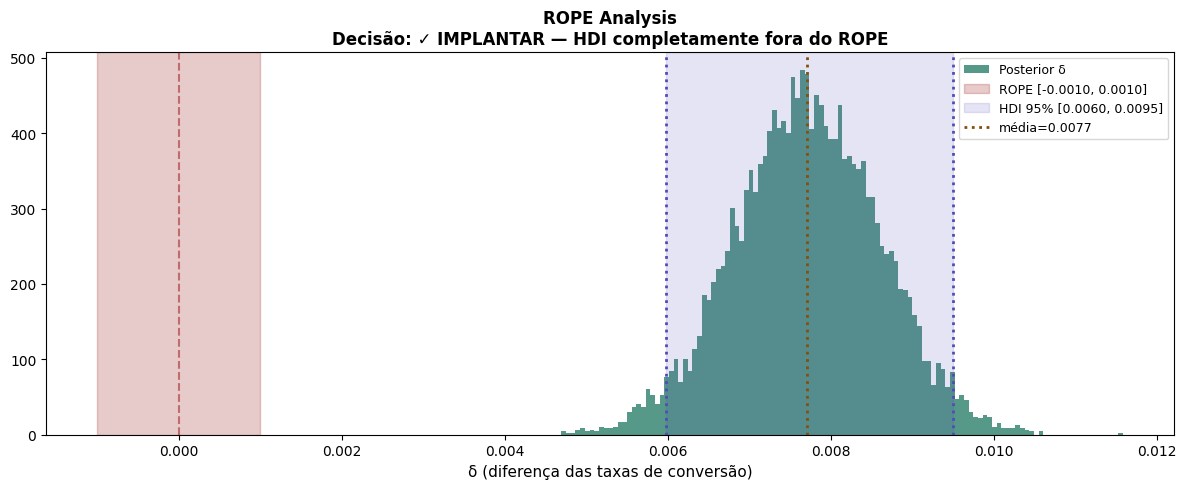

✓ Gráfico salvo em reports/


In [4]:
# ── CÉLULA 2: gráfico ROPE ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(samples_delta, bins=120, density=True,
        color='#0F6E56', alpha=0.7, label='Posterior δ')

ax.axvspan(rope_low, rope_high, alpha=0.25, color='#A32D2D',
           label=f'ROPE [{rope_low:.4f}, {rope_high:.4f}]')
ax.axvspan(hdi_delta[0], hdi_delta[1], alpha=0.15, color='#534AB7',
           label=f'HDI 95% [{hdi_delta[0]:.4f}, {hdi_delta[1]:.4f}]')

ax.axvline(0, color='#A32D2D', lw=1.5, linestyle='--', alpha=0.6)
ax.axvline(hdi_delta[0], color='#534AB7', lw=2, linestyle=':')
ax.axvline(hdi_delta[1], color='#534AB7', lw=2, linestyle=':')
ax.axvline(samples_delta.mean(), color='#854F0B', lw=2,
           linestyle=':', label=f'média={samples_delta.mean():.4f}')

ax.set_xlabel('δ (diferença das taxas de conversão)', fontsize=11)
ax.set_title(f'ROPE Analysis\nDecisão: {decisao}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{BASE}/reports/rope_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo em reports/")

In [5]:
# ── CÉLULA 3: Bayes Factor (Savage-Dickey) ───────────────────────────────────
prior_samples_ad  = scipy_stats.beta.rvs(2, 98, size=100000, random_state=42)
prior_samples_psa = scipy_stats.beta.rvs(2, 98, size=100000, random_state=43)
prior_delta       = prior_samples_ad - prior_samples_psa

kde_prior     = gaussian_kde(prior_delta)
kde_posterior = gaussian_kde(samples_delta)

prior_at_0     = kde_prior(0)[0]
posterior_at_0 = kde_posterior(0)[0]

BF10 = prior_at_0 / posterior_at_0

def classificar_bf(bf):
    if bf > 100:  return 'Decisiva (> 100)'
    if bf > 30:   return 'Muito forte (30–100)'
    if bf > 10:   return 'Forte (10–30)'
    if bf > 3:    return 'Moderada (3–10)'
    if bf > 1:    return 'Anedótica (1–3)'
    return 'Favorece H0'

print('BAYES FACTOR — Savage-Dickey')
print('─'*48)
print(f'  prior(delta=0)     : {prior_at_0:.6f}')
print(f'  posterior(delta=0) : {posterior_at_0:.10f}')
print(f'  BF10               : {BF10:.4e}')
print(f'  Classificação      : {classificar_bf(BF10)}')
print(f'\n  Interpretação:')
print(f'  Os dados são {BF10:.2e}x mais prováveis sob H1')
print(f'  (efeito existe) do que sob H0 (sem efeito).')

BAYES FACTOR — Savage-Dickey
────────────────────────────────────────────────
  prior(delta=0)     : 24.996730
  posterior(delta=0) : 0.0000000000
  BF10               : 1.7050e+220
  Classificação      : Decisiva (> 100)

  Interpretação:
  Os dados são 1.70e+220x mais prováveis sob H1
  (efeito existe) do que sob H0 (sem efeito).


## 🔢 Interpretando o Bayes Factor

BF10 = 1.70 × 10²²⁰ significa que os dados são **10²²⁰ vezes mais prováveis**
sob H1 (efeito existe) do que sob H0 (sem efeito).

Para referência: o número de átomos no universo observável é ~10⁸⁰.

Na escala de Jeffreys: **Evidência Decisiva** (BF > 100).

> ⚠️ Nota de maturidade estatística: um BF tão extremo não significa que o efeito
> é grande — significa apenas que a evidência contra H0 é esmagadora. O tamanho
> do efeito (delta médio = 0.77pp, Cohen's h = 0.053) continua sendo pequeno.
> O ROPE é o instrumento correto para avaliar relevância prática.

In [6]:
# ── CÉLULA 4: parada adaptativa ──────────────────────────────────────────────
P_THRESH   = 0.95
HDI_THRESH = 0.005
STEP       = 5000
N_MAX      = len(df)

df_sorted = df.sort_values('most_ads_day').reset_index(drop=True)

historico     = []
decisao_final = None

for n in range(STEP, N_MAX + STEP, STEP):
    subset = df_sorted.iloc[:n]
    n_a = int((subset.test_group=='ad').sum())
    n_p = int((subset.test_group=='psa').sum())
    c_a = int(subset[subset.test_group=='ad']['converted'].sum())
    c_p = int(subset[subset.test_group=='psa']['converted'].sum())

    if n_a == 0 or n_p == 0: continue

    # Posterior analítico Beta conjugado
    samp_a = scipy_stats.beta.rvs(2 + c_a, 98 + n_a - c_a, size=5000)
    samp_p = scipy_stats.beta.rvs(2 + c_p, 98 + n_p - c_p, size=5000)
    delta_s = samp_a - samp_p

    p_melhor = (delta_s > 0).mean()
    hdi_w    = np.percentile(delta_s, 97.5) - np.percentile(delta_s, 2.5)

    historico.append({'n': n, 'p_melhor': p_melhor, 'hdi_width': hdi_w})

    if decisao_final is None:
        if p_melhor > P_THRESH:
            decisao_final = (n, 'IMPLANTAR ad', p_melhor)
        elif p_melhor < 1 - P_THRESH:
            decisao_final = (n, 'MANTER psa', p_melhor)
        elif hdi_w < HDI_THRESH:
            decisao_final = (n, 'PARAR por precisão HDI', p_melhor)

df_hist = pd.DataFrame(historico)

print('PARADA ADAPTATIVA')
print('─'*48)
if decisao_final:
    economia = 1 - decisao_final[0] / N_MAX
    print(f'  Decisão em n        : {decisao_final[0]:,}')
    print(f'  Ação                : {decisao_final[1]}')
    print(f'  P(ad>psa) na parada : {decisao_final[2]:.4%}')
    print(f'  n_max do dataset    : {N_MAX:,}')
    print(f'  Economia            : {economia:.1%} das observações')

PARADA ADAPTATIVA
────────────────────────────────────────────────
  Decisão em n        : 15,000
  Ação                : IMPLANTAR ad
  P(ad>psa) na parada : 97.1400%
  n_max do dataset    : 588,101
  Economia            : 97.4% das observações


## ⏱️ Parada Adaptativa — Insight

O experimento poderia ter sido encerrado com **n=15.000** (2.6% dos dados coletados).

| | Frequentista | Bayesiano adaptativo |
|---|---|---|
| **n necessário** | 588.101 (fixo) | 15.000 (adaptativo) |
| **Decisão** | p-valor < 0.05 | P(ad > psa) = 97.14% |
| **Economia** | — | 97.4% das observações |

> Em empresas de produto, isso significa semanas a menos de experimento,
> menor risco de exposição a uma variante inferior, e decisão mais rápida.

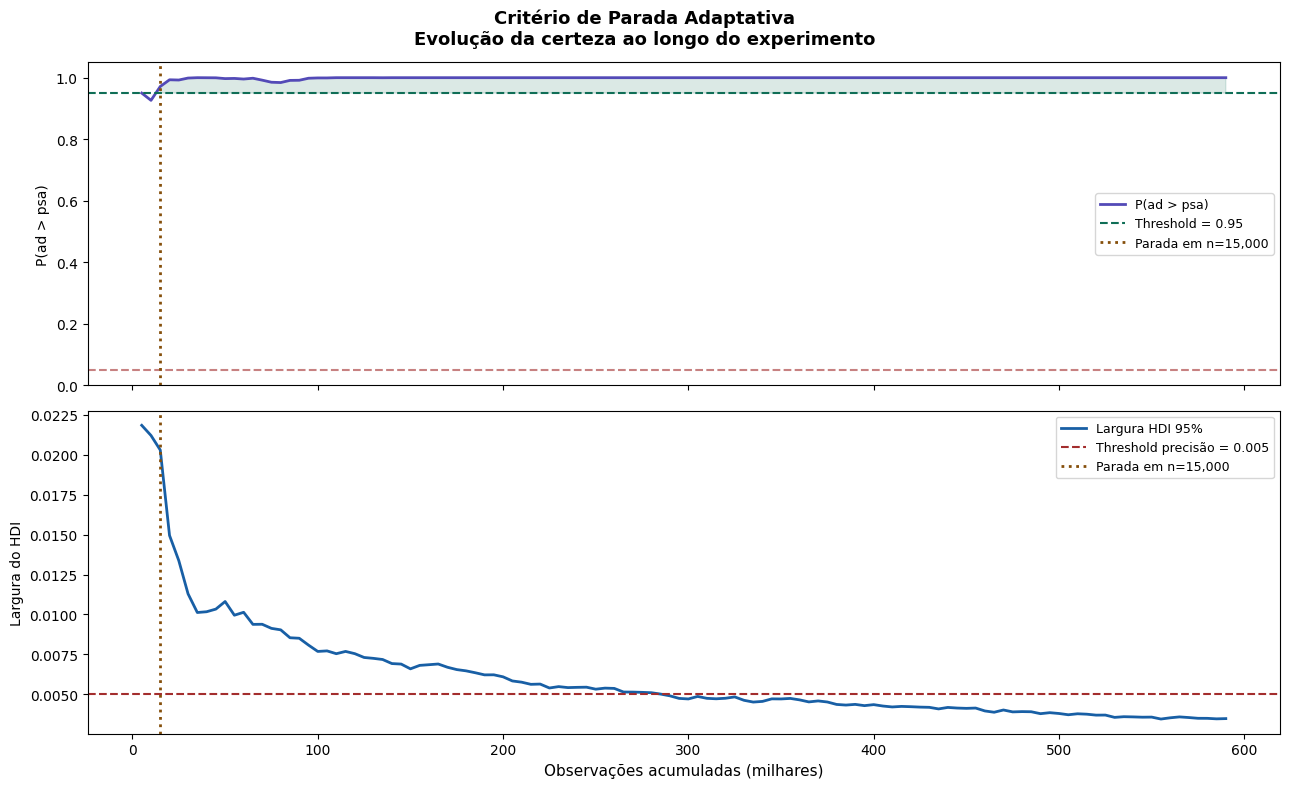

✓ Gráfico salvo em reports/


In [7]:
# ── CÉLULA 5: gráfico parada adaptativa ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Critério de Parada Adaptativa\nEvolução da certeza ao longo do experimento',
             fontsize=13, fontweight='bold')

n_vals = df_hist['n'] / 1000

# Plot 1: P(ad > psa)
axes[0].plot(n_vals, df_hist['p_melhor'], color='#534AB7', lw=2, label='P(ad > psa)')
axes[0].axhline(P_THRESH, color='#0F6E56', lw=1.5, linestyle='--',
                label=f'Threshold = {P_THRESH}')
axes[0].axhline(1 - P_THRESH, color='#A32D2D', lw=1.5, linestyle='--', alpha=0.6)
axes[0].axvline(decisao_final[0]/1000, color='#854F0B', lw=2, linestyle=':',
                label=f'Parada em n={decisao_final[0]:,}')
axes[0].fill_between(n_vals, df_hist['p_melhor'], P_THRESH,
                     where=df_hist['p_melhor'] >= P_THRESH,
                     alpha=0.15, color='#0F6E56')
axes[0].set_ylabel('P(ad > psa)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

# Plot 2: largura HDI
axes[1].plot(n_vals, df_hist['hdi_width'], color='#185FA5', lw=2, label='Largura HDI 95%')
axes[1].axhline(HDI_THRESH, color='#A32D2D', lw=1.5, linestyle='--',
                label=f'Threshold precisão = {HDI_THRESH}')
axes[1].axvline(decisao_final[0]/1000, color='#854F0B', lw=2, linestyle=':',
                label=f'Parada em n={decisao_final[0]:,}')
axes[1].set_xlabel('Observações acumuladas (milhares)', fontsize=11)
axes[1].set_ylabel('Largura do HDI')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/parada_adaptativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo em reports/")

In [8]:
# ── CÉLULA 6: modelo hierárquico por dia da semana ───────────────────────────
dias         = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_ad        = df[df.test_group == 'ad']
n_por_dia    = df_ad.groupby('most_ads_day')['converted'].count().reindex(dias).values
conv_por_dia = df_ad.groupby('most_ads_day')['converted'].sum().reindex(dias).values
n_dias       = len(dias)

with pm.Model() as modelo_hierarquico:
    mu_alpha    = pm.Normal('mu_alpha', mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)
    alpha_offset= pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_dias)
    alpha       = pm.Deterministic('alpha', mu_alpha + sigma_alpha * alpha_offset)
    theta       = pm.Deterministic('theta', pm.math.sigmoid(alpha))
    obs         = pm.Binomial('obs', n=n_por_dia, p=theta, observed=conv_por_dia)
    trace_h     = pm.sample(draws=2000, chains=4, target_accept=0.9,
                            return_inferencedata=True, progressbar=True)

print('✓ Modelo hierárquico concluído!')

# Diagnósticos
rhat_theta = float(az.rhat(trace_h)['theta'].max())
ess_theta  = float(az.ess(trace_h)['theta'].min())
print(f'  R-hat máx (theta): {rhat_theta:.4f}  {"✓" if rhat_theta < 1.01 else "✗"}')
print(f'  ESS mín  (theta): {ess_theta:.0f}   {"✓" if ess_theta > 400 else "✗"}')

Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


✓ Modelo hierárquico concluído!
  R-hat máx (theta): 1.0010  ✓
  ESS mín  (theta): 8783   ✓


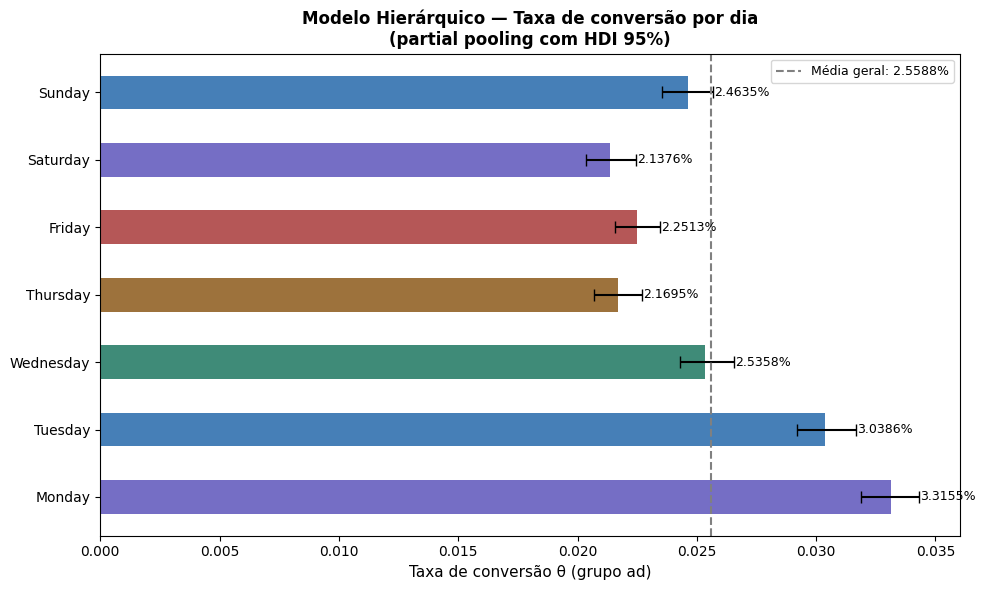


Ranking — taxa de conversão por dia (grupo ad):
  1. Monday       3.3155%
  2. Tuesday      3.0386%
  3. Wednesday    2.5358%
  4. Sunday       2.4635%
  5. Friday       2.2513%
  6. Thursday     2.1695%
  7. Saturday     2.1376%


In [9]:
# ── CÉLULA 7: forest plot hierárquico ────────────────────────────────────────
theta_samples = trace_h.posterior['theta'].values.reshape(-1, n_dias)
theta_mean    = theta_samples.mean(axis=0)
theta_hdi_v   = az.hdi(trace_h, var_names=['theta'], hdi_prob=0.95)['theta'].values

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#534AB7','#185FA5','#0F6E56','#854F0B','#A32D2D','#534AB7','#185FA5']

for i, (dia, cor) in enumerate(zip(dias, cores)):
    ax.barh(dia, theta_mean[i],
            xerr=[[theta_mean[i] - theta_hdi_v[i, 0]],
                  [theta_hdi_v[i, 1] - theta_mean[i]]],
            color=cor, alpha=0.8, capsize=4, height=0.5)
    ax.text(theta_hdi_v[i, 1] + 0.00005, i,
            f'{theta_mean[i]:.4%}', va='center', fontsize=9)

ax.axvline(theta_mean.mean(), color='gray', lw=1.5, linestyle='--',
           label=f'Média geral: {theta_mean.mean():.4%}')
ax.set_xlabel('Taxa de conversão θ (grupo ad)', fontsize=11)
ax.set_title('Modelo Hierárquico — Taxa de conversão por dia\n(partial pooling com HDI 95%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{BASE}/reports/hierarquico_dias.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranking dos dias
ranking = sorted(zip(dias, theta_mean), key=lambda x: x[1], reverse=True)
print('\nRanking — taxa de conversão por dia (grupo ad):')
for i, (dia, taxa) in enumerate(ranking, 1):
    print(f'  {i}. {dia:<12} {taxa:.4%}')

## 🗓️ Insight do Modelo Hierárquico

O partial pooling revela padrão semanal claro no grupo `ad`:

| Dia | Taxa | vs média |
|---|---|---|
| **Monday** | 3.3155% | +29.7% |
| **Tuesday** | 3.0386% | +18.9% |
| Wednesday | 2.5358% | −0.9% |
| Sunday | 2.4635% | −3.7% |
| Friday | 2.2513% | −12.0% |
| Thursday | 2.1695% | −15.2% |
| Saturday | 2.1376% | −16.4% |

**Recomendação:** concentrar veiculação de ads na segunda e terça pode
aumentar a taxa de conversão efetiva sem aumentar o investimento.

> O modelo hierárquico com partial pooling é superior a estimar cada dia
> separadamente: dias com poucos dados "emprestam força" dos demais via
> prior hierárquico, evitando overfitting.

In [10]:
# ── CÉLULA 8: salvar notebook no Drive ───────────────────────────────────────
import shutil, glob

for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')
print("\nResumo da Fase 3:")
print("  reports/ → rope_analysis.png")
print("  reports/ → parada_adaptativa.png")
print("  reports/ → hierarquico_dias.png")
print("  notebooks/ → 02_rope_bf_sequential.ipynb")

✓ Notebook salvo em: /content/drive/MyDrive/Inferência Bayesiana Aplicada/notebooks/

Resumo da Fase 3:
  reports/ → rope_analysis.png
  reports/ → parada_adaptativa.png
  reports/ → hierarquico_dias.png
  notebooks/ → 02_rope_bf_sequential.ipynb
